In [ ]:
import tkinter as tk
from PIL import Image, ImageDraw
import numpy as np

class AplicacionDibujo:
    def __init__(self, master, ancho=500, alto=500):
        self.master = master
        self.master.title("Escoge tu edad")
        
        self.ancho = ancho
        self.alto = alto
        self.color_actual = "black"
        self.grosor = 5
        
        # 1. Crear la imagen en memoria (Pillow) donde guardaremos los datos reales
        self.imagen_pil = Image.new("RGB", (self.ancho, self.alto), "white")
        self.dibujo_pil = ImageDraw.Draw(self.imagen_pil)
        
        # 2. Crear la interfaz gráfica (Tkinter)
        self.canvas = tk.Canvas(self.master, width=self.ancho, height=self.alto, bg="white")
        self.canvas.pack(pady=10)
        
        # Bindings para el ratón
        self.canvas.bind("<B1-Motion>", self.dibujar)
        self.canvas.bind("<ButtonRelease-1>", self.resetear_coordenadas)
        
        self.x_anterior = None
        self.y_anterior = None
        
        # 3. Panel de herramientas (Botones)
        frame_herramientas = tk.Frame(self.master)
        frame_herramientas.pack(fill="x", padx=10, pady=5)
        
        colores = ["black", "red", "blue", "green", "yellow", "purple", "orange", "brown", "white"]
        for color in colores:
            btn = tk.Button(frame_herramientas, bg=color, width=3, 
                            command=lambda c=color: self.cambiar_color(c))
            btn.pack(side="left", padx=2)
        
        grosores = [1, 3, 5, 7, 10]
        for g in grosores:
            btn = tk.Button(frame_herramientas, text=str(g), width=3, 
                            command=lambda gr=g: self.cambiar_grosor(gr))
            btn.pack(side="left", padx=2)
        
        btn = tk.Button(frame_herramientas, bg="white", width=7, 
                            command=lambda c="white": self.borrar())
        btn.pack(side="left", padx=2)

        btn_terminar = tk.Button(frame_herramientas, text="Guardar", 
                                 command=self.terminar)
        btn_terminar.pack(side="right")
        
        # Variable para almacenar el resultado final
        self.imagen_resultado = None

    def cambiar_color(self, nuevo_color):
        self.color_actual = nuevo_color
    
    def cambiar_grosor(self, nuevo_grosor):
        self.grosor = nuevo_grosor

    def dibujar(self, evento):
        # Si tenemos coordenadas anteriores, dibujamos una línea desde allí hasta la posición actual
        if self.x_anterior and self.y_anterior:
            # Dibujar en la pantalla (Tkinter)
            self.canvas.create_line(self.x_anterior, self.y_anterior, evento.x, evento.y, 
                                    width=self.grosor, fill=self.color_actual, 
                                    capstyle=tk.ROUND, smooth=tk.TRUE)
            # Dibujar en la imagen de memoria (Pillow)
            self.dibujo_pil.line([self.x_anterior, self.y_anterior, evento.x, evento.y], 
                                 fill=self.color_actual, width=self.grosor)
            
        self.x_anterior = evento.x
        self.y_anterior = evento.y
    
    def borrar(self):
        self.color_actual = "white"

    def resetear_coordenadas(self, evento):
        self.x_anterior = None
        self.y_anterior = None

    def terminar(self):
        # Convertir la imagen de Pillow a un array de NumPy (ideal para procesar)
        self.imagen_resultado = np.array(self.imagen_pil)
        # Cerrar la ventana
        self.master.destroy()

def procesar_imagen(imagen_array):
    print("\n--- Procesando Imagen ---")
    print(f"Tipo de dato: {type(imagen_array)}")
    print(f"Dimensiones de la imagen (Alto, Ancho, Canales RGB): {imagen_array.shape}")

def main():
    # Inicializar Tkinter
    root = tk.Tk()
    app = AplicacionDibujo(root)
    
    # Iniciar el bucle de la ventana (el código se detiene aquí hasta que se cierre la ventana)
    root.mainloop()
    
    # Una vez cerrada la ventana, comprobamos si hay un resultado y lo pasamos a la otra función
    if app.imagen_resultado is not None:
        procesar_imagen(app.imagen_resultado)
        return app.imagen_resultado
    else:
        print("La ventana se cerró sin guardar la imagen.")

In [31]:
img = main()


--- Procesando Imagen ---
Tipo de dato: <class 'numpy.ndarray'>
Dimensiones de la imagen (Alto, Ancho, Canales RGB): (500, 500, 3)


Normalizamos la imagen (dividiendo entre $255$) e invertimos sus colores (para que el fondo sea negro y, por tanto, la matriz sparse).

In [32]:
img_norm = 1 - img/255
img_norm

array([[[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       ...,

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]])

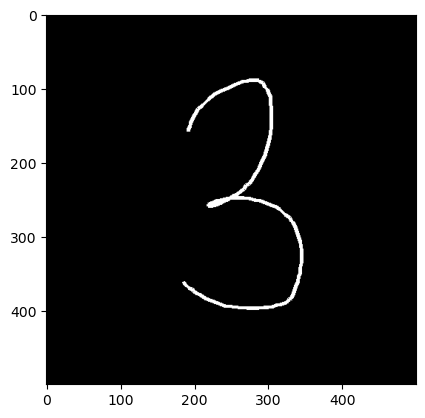

In [33]:
import matplotlib.pyplot as plt
plt.imshow(img_norm)

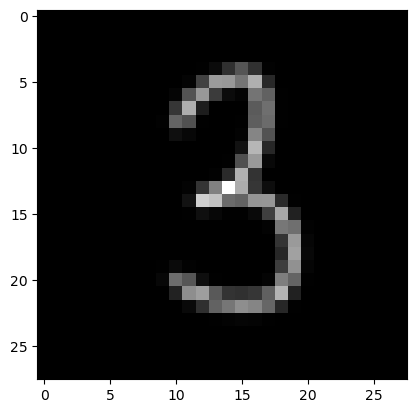

In [34]:
from skimage.transform import resize
resized_img = resize(img_norm, (28, 28))
resized_img = resized_img/resized_img.max()
plt.imshow(resized_img, cmap = "gray")